# Visual-Inertial Odometry on KITTI Autonomous Vehicle Data

We run a **VIO pipeline** on real self-driving car data from the
[KITTI Raw Dataset](https://www.cvlibs.net/datasets/kitti/raw_data.php).

The car carries:
- **Stereo grayscale cameras** (10 Hz, 1242x375)
- **IMU** (100 Hz) — accelerometer + gyroscope from an OXTS RT3003
- **GPS** (100 Hz) — used as ground truth

## What VIO adds over pure VO
```
Pure VO:   camera -> features -> Essential matrix -> pose
                    FAILS on blur, dark frames, plain walls

IMU only:  integrate acceleration + angular rate -> pose
                    DRIFTS as t^2 (noise integrates twice for position)

VIO:       IMU gives motion prior -> camera refines + bounds drift
           Camera resets IMU drift -> IMU handles fast motion
```

## Pipeline
```
Download KITTI -> parse calibration -> load frames + IMU
-> VO (SIFT) -> IMU dead-reckoning -> GPS ground truth (ENU)
-> three-way trajectory comparison
```


In [3]:
!pip install opencv-contrib-python --quiet

import cv2, os, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime

print(f'OpenCV {cv2.__version__}  |  NumPy {np.__version__}')


OpenCV 4.13.0  |  NumPy 2.0.2


---
## Step 0 — Download KITTI Raw (drive 0001, ~380 MB)

Two zips from the public KITTI S3 bucket:
1. **Calibration** — camera intrinsics, IMU-camera extrinsics
2. **Drive 0001** — 108 frames, city scene

We extract only `image_00` (left grayscale) and `oxts` (IMU + GPS).


In [2]:
DATE  = '2011_09_26'
DRIVE = '2011_09_26_drive_0001'
BASE  = 'https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data'

CALIB_URL = f'{BASE}/{DATE}_calib.zip'
DRIVE_URL = f'{BASE}/{DRIVE}/{DRIVE}_sync.zip'


def download_and_extract(url, zip_path, dest, keep_prefixes=None):
    if not os.path.exists(zip_path):
        print(f'Downloading {os.path.basename(url)} ...')
        urllib.request.urlretrieve(url, zip_path)
        print(f'  saved to {zip_path}')
    print(f'Extracting ...')
    with zipfile.ZipFile(zip_path) as z:
        members = z.namelist()
        if keep_prefixes:
            members = [m for m in members
                       if any(p in m for p in keep_prefixes)]
        for m in members:
            z.extract(m, dest)
    print(f'  done ({len(members)} files)')


os.makedirs('/content', exist_ok=True)
download_and_extract(CALIB_URL, '/content/kitti_calib.zip', '/content')
download_and_extract(DRIVE_URL, '/content/kitti_drive.zip', '/content',
                     keep_prefixes=['image_00', 'oxts'])
print('All done.')


  saved to /content/kitti_calib.zip
Extracting ...
  done (3 files)
  saved to /content/kitti_drive.zip
Extracting ...
  done (223 files)
All done.


---
## Step 1 — Set Paths & Parse Calibration

Confirmed directory structure after extraction:
```
/content/2011_09_26/
  calib_cam_to_cam.txt
  calib_imu_to_velo.txt
  calib_velo_to_cam.txt
  2011_09_26_drive_0001_sync/
    image_00/
      timestamps.txt
      data/0000000000.png ...
    oxts/
      timestamps.txt
      dataformat.txt
      data/0000000000.txt ...
```

We read `P_rect_00` from `calib_cam_to_cam.txt` — a 3x4 rectified
projection matrix whose left 3x3 block is the intrinsic matrix K:
```
P_rect_00 = [fx   0  cx  0]
             [ 0  fy  cy  0]     =>    K = P_rect_00[:3, :3]
             [ 0   0   1  0]
```


In [4]:
# ── Confirmed paths (matching actual extracted structure) ─────────────────────
DRIVE_ROOT = f'/content/{DATE}/{DRIVE}_sync'
IMG_DIR    = f'{DRIVE_ROOT}/image_00/data'
OXTS_DIR   = f'{DRIVE_ROOT}/oxts/data'
TS_IMG     = f'{DRIVE_ROOT}/image_00/timestamps.txt'
TS_OXTS    = f'{DRIVE_ROOT}/oxts/timestamps.txt'
CALIB_FILE = f'/content/{DATE}/calib_cam_to_cam.txt'

# Sanity check
print('Path check:')
for p in [IMG_DIR, OXTS_DIR, TS_IMG, TS_OXTS, CALIB_FILE]:
    print(f'  {"OK  " if os.path.exists(p) else "MISSING"}  {p}')


# ── Parse K from calibration file ────────────────────────────────────────────
def parse_kitti_calib(calib_file):
    """
    Read calib_cam_to_cam.txt and return K (3x3) for camera 0.
    P_rect_00 is a 3x4 matrix; the left 3x3 block is the intrinsic matrix K.
    """
    with open(calib_file) as f:
        for line in f:
            if line.startswith('P_rect_00:'):
                vals = list(map(float, line.split()[1:]))
                return np.array(vals).reshape(3, 4)[:3, :3]
    raise ValueError('P_rect_00 not found in calib_cam_to_cam.txt')


K = parse_kitti_calib(CALIB_FILE)
print(f'\nIntrinsic matrix K:')
print(K)
fov_h = 2 * np.degrees(np.arctan(1242 / (2 * K[0, 0])))
print(f'Horizontal FOV: {fov_h:.1f} deg')


Path check:
  OK    /content/2011_09_26/2011_09_26_drive_0001_sync/image_00/data
  OK    /content/2011_09_26/2011_09_26_drive_0001_sync/oxts/data
  OK    /content/2011_09_26/2011_09_26_drive_0001_sync/image_00/timestamps.txt
  OK    /content/2011_09_26/2011_09_26_drive_0001_sync/oxts/timestamps.txt
  OK    /content/2011_09_26/calib_cam_to_cam.txt

Intrinsic matrix K:
[[721.5377   0.     609.5593]
 [  0.     721.5377 172.854 ]
 [  0.       0.       1.    ]]
Horizontal FOV: 81.4 deg


---
## Step 2 — Load Frames & IMU/GPS

Camera runs at **10 Hz**, IMU/GPS at **100 Hz**.

### KITTI oxts data format
Each `oxts/data/XXXXXXXXXX.txt` has 30 space-separated columns:
```
col  0-2 : lat, lon, alt       (GPS position, degrees / metres)
col  3-5 : roll, pitch, yaw    (orientation, radians)
col 11-13: ax, ay, az          (linear acceleration, body frame, m/s^2)
col 17-19: wx, wy, wz          (angular rate, body frame, rad/s)
```


Camera frames : 50  shape (375, 1242)
Camera freq   : ~4.8 Hz
IMU samples   : 108
IMU freq      : ~10 Hz


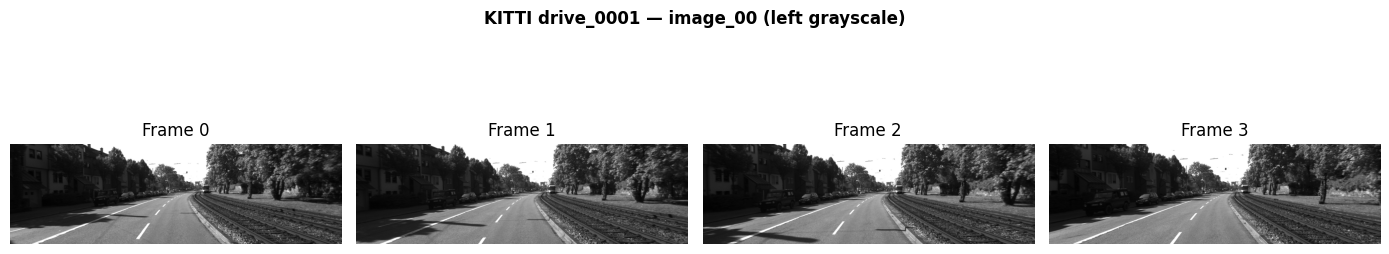

In [5]:
def parse_timestamps(ts_file):
    """
    Parse KITTI timestamp file -> array of floats (seconds).
    Format: '2011-09-26 13:02:42.279165765'
    We truncate to microseconds (Python datetime max precision).
    """
    times = []
    with open(ts_file) as f:
        for line in f:
            line = line.strip()
            if line:
                dt = datetime.strptime(line[:26], '%Y-%m-%d %H:%M:%S.%f')
                times.append(dt.timestamp())
    return np.array(times)


# ── Camera timestamps & frames ────────────────────────────────────────────────
cam_ts  = parse_timestamps(TS_IMG)
cam_ts -= cam_ts[0]                    # zero-base

STEP       = 2
MAX_FRAMES = 50

img_files  = sorted(os.listdir(IMG_DIR))[::STEP][:MAX_FRAMES]
frames     = [cv2.imread(os.path.join(IMG_DIR, f), cv2.IMREAD_GRAYSCALE)
              for f in img_files]
frames     = [f for f in frames if f is not None]
cam_ts_sel = cam_ts[::STEP][:len(frames)]

# ── IMU / GPS ─────────────────────────────────────────────────────────────────
oxts_ts  = parse_timestamps(TS_OXTS)
oxts_ts -= oxts_ts[0]

oxts_data = np.array([
    list(map(float, open(os.path.join(OXTS_DIR, f)).read().split()))
    for f in sorted(os.listdir(OXTS_DIR))
])  # shape (N_imu, 30)

print(f'Camera frames : {len(frames)}  shape {frames[0].shape}')
print(f'Camera freq   : ~{1/np.diff(cam_ts_sel).mean():.1f} Hz')
print(f'IMU samples   : {len(oxts_data)}')
print(f'IMU freq      : ~{1/np.diff(oxts_ts).mean():.0f} Hz')

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, f, i in zip(axes, frames[:4], range(4)):
    ax.imshow(f, cmap='gray'); ax.set_title(f'Frame {i}'); ax.axis('off')
fig.suptitle('KITTI drive_0001 — image_00 (left grayscale)', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Step 3 — IMU Dead Reckoning

Between camera frames (~0.1-0.2 s apart) the IMU fires ~10-20 times.

### Integration equations (first-order Euler)
```
For each IMU sample (angular rate w, acceleration a_body, timestep dt):

  R_new = R_old @ Exp(w * dt)            # Rodrigues exponential map
  a_world = R_old @ a_body - [0,0,9.81]  # remove gravity
  v_new = v_old + a_world * dt
  p_new = p_old + v_old * dt
```
Bias + noise integrates twice into position -> error grows as t^2.
Real VIO (VINS-Mono, OKVIS) corrects this with a factor graph.


In [6]:
def rodrigues_exp(w, dt):
    """
    Rodrigues exponential map: rotation matrix for angular velocity w over dt.
    R = I + sin(theta)/theta * [w]x + (1-cos(theta))/theta^2 * [w]x^2
    where theta = ||w|| * dt  and  [w]x is the skew-symmetric matrix of w.
    Falls back to I + [w*dt]x for near-zero theta.
    """
    theta = np.linalg.norm(w) * dt
    if theta < 1e-8:
        wdt = w * dt
        K = np.array([[0,-wdt[2],wdt[1]],[wdt[2],0,-wdt[0]],[-wdt[1],wdt[0],0]])
        return np.eye(3) + K
    ax = w / np.linalg.norm(w)
    K  = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
    return np.eye(3) + np.sin(theta)*K + (1-np.cos(theta))*(K@K)


def integrate_imu(oxts_data, oxts_ts, g_mag=9.81):
    """
    Euler integration of all IMU samples -> position trajectory.

    Columns used:
      [3,4,5]   roll, pitch, yaw  (used to initialise R at t=0)
      [11,12,13] ax, ay, az       (linear acceleration, body frame)
      [17,18,19] wx, wy, wz       (angular rate, body frame)

    Returns positions (N, 3) in world frame (metres).
    """
    def euler_to_R(roll, pitch, yaw):
        cr,sr = np.cos(roll),  np.sin(roll)
        cp,sp = np.cos(pitch), np.sin(pitch)
        cy,sy = np.cos(yaw),   np.sin(yaw)
        Rz = np.array([[cy,-sy,0],[sy,cy,0],[0,0,1]])
        Ry = np.array([[cp,0,sp],[0,1,0],[-sp,0,cp]])
        Rx = np.array([[1,0,0],[0,cr,-sr],[0,sr,cr]])
        return Rz @ Ry @ Rx

    g_world = np.array([0, 0, g_mag])
    R = euler_to_R(oxts_data[0,3], oxts_data[0,4], oxts_data[0,5])
    v = np.zeros(3)
    p = np.zeros(3)
    positions = [p.copy()]

    for i in range(1, len(oxts_data)):
        dt = oxts_ts[i] - oxts_ts[i-1]
        if dt <= 0 or dt > 1.0:
            positions.append(p.copy())
            continue
        a_body = oxts_data[i, 11:14]
        w_body = oxts_data[i, 17:20]
        R = R @ rodrigues_exp(w_body, dt)
        a_world = R @ a_body - g_world
        p = p + v * dt
        v = v + a_world * dt
        positions.append(p.copy())

    return np.array(positions)


imu_traj = integrate_imu(oxts_data, oxts_ts)
print(f'IMU trajectory: {imu_traj.shape}')
print(f'IMU path length: {np.sum(np.linalg.norm(np.diff(imu_traj,axis=0),axis=1)):.2f} m')


IMU trajectory: (108, 3)
IMU path length: 39.89 m


---
## Step 4 — GPS Ground Truth (ENU Coordinates)

Convert lat/lon/alt to local ENU (East-North-Up) frame:
```
N     = a / sqrt(1 - e^2 * sin(lat0)^2)     radius of curvature
east  = N * cos(lat0) * (lon - lon0) * pi/180
north = N * (lat - lat0) * pi/180
up    = alt - alt0
```
Valid for drives < ~100 km. WGS84: a=6378137 m, e^2=0.00669438.


In [7]:
def latlon_to_enu(lat, lon, alt, lat0, lon0, alt0):
    """
    GPS lat/lon/alt -> local ENU coordinates (metres).
    Flat-Earth approximation with WGS84 ellipsoid.
    """
    a  = 6378137.0
    e2 = 0.00669437999014
    lat0_r = np.radians(lat0)
    N      = a / np.sqrt(1 - e2 * np.sin(lat0_r)**2)
    east   = N * np.cos(lat0_r) * np.radians(lon - lon0)
    north  = N * np.radians(lat - lat0)
    up     = alt - alt0
    return east, north, up


lat0, lon0, alt0 = oxts_data[0,0], oxts_data[0,1], oxts_data[0,2]
gps_enu = np.array([
    latlon_to_enu(r[0],r[1],r[2], lat0,lon0,alt0)
    for r in oxts_data
])

print(f'GPS trajectory : {gps_enu.shape}')
print(f'Total distance : {np.sum(np.linalg.norm(np.diff(gps_enu,axis=0),axis=1)):.2f} m')
print(f'East range     : {gps_enu[:,0].min():.1f} .. {gps_enu[:,0].max():.1f} m')
print(f'North range    : {gps_enu[:,1].min():.1f} .. {gps_enu[:,1].max():.1f} m')


GPS trajectory : (108, 3)
Total distance : 107.17 m
East range     : -96.9 .. 0.0 m
North range    : -45.4 .. 0.0 m


---
## Step 5 — SIFT VO Pipeline

Same SIFT + Essential matrix pipeline as before.
Frames with inlier ratio < 10% are skipped (pose held) to avoid
corrupting the trajectory from blur or featureless regions.


In [8]:
def detect_and_describe(img, n=3000):
    sift = cv2.SIFT_create(nfeatures=n, nOctaveLayers=3,
                            contrastThreshold=0.04, edgeThreshold=10, sigma=1.6)
    return sift.detectAndCompute(img, mask=None)


def match_features(d1, d2, ratio=0.75):
    if d1 is None or d2 is None: return []
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    pairs = bf.knnMatch(d1, d2, k=2)
    return [m for m,n in pairs
            if len([m,n])==2 and m.distance < ratio*n.distance]


def extract_pts(kp1, kp2, matches):
    p1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    p2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)
    return p1, p2


def estimate_motion(p1, p2, K, thresh=1.0):
    """
    Essential matrix via 5-point RANSAC -> R, t (unit vector).
    Sampson distance used as RANSAC error metric.
    cheirality check picks the (R,t) with points in front of both cameras.
    """
    if p1.shape[0] < 5:
        return np.eye(3), np.zeros((3,1)), None
    E, mask = cv2.findEssentialMat(
        p1, p2, cameraMatrix=K,
        method=cv2.RANSAC, prob=0.999, threshold=thresh)
    if E is None:
        return np.eye(3), np.zeros((3,1)), None
    _, R, t, mask = cv2.recoverPose(E, p1, p2, cameraMatrix=K, mask=mask)
    return R, t, mask


def build_T(R, t):
    T = np.eye(4); T[:3,:3]=R; T[:3,3]=t.ravel(); return T


def run_vo(frames, K, n=2000, ratio=0.75, thresh=1.0, min_inlier_ratio=0.10):
    """
    VO with bad-frame rejection.
    Frames where inlier_count/match_count < min_inlier_ratio are skipped:
    the previous pose is held instead of composing a corrupted delta_T.
    """
    T_g = np.eye(4)
    poses = [T_g.copy()]
    stats = []
    kp_p, d_p = detect_and_describe(frames[0], n)

    for i in range(1, len(frames)):
        kp_c, d_c = detect_and_describe(frames[i], n)
        ms = match_features(d_p, d_c, ratio)

        skip    = False
        inliers = 0
        if len(ms) >= 5:
            p1, p2     = extract_pts(kp_p, kp_c, ms)
            R, t, mask = estimate_motion(p1, p2, K, thresh)
            inliers    = int(mask.sum()) if mask is not None else 0
            if inliers / len(ms) < min_inlier_ratio:
                skip = True
        else:
            R, t = np.eye(3), np.zeros((3,1))
            skip = True

        if not skip:
            T_g = T_g @ build_T(R, t)

        poses.append(T_g.copy())
        stats.append({'matches': len(ms), 'inliers': inliers, 'skipped': skip})
        kp_p, d_p = kp_c, d_c

    skipped = sum(1 for s in stats if s['skipped'])
    print(f'Done. {len(frames)} frames, {skipped} skipped.')
    return poses, stats


print('Running VO ...')
poses, stats = run_vo(frames, K)


Running VO ...
Done. 50 frames, 0 skipped.


---
## Step 6 — Trajectory Alignment

Three trajectories, different frames and scales:

| Trajectory | Frame | Scale |
|------------|-------|-------|
| VO  | camera, unit steps | unknown |
| IMU | world (body-aligned) | metric (m) |
| GPS | ENU, WGS84 | metric (m) |

We sample GPS and IMU at camera timestamps (nearest-neighbour),
centre all at origin, then scale VO to match GPS path length.

**ATE** = sqrt( (1/N) * sum ||p_est_i - p_gps_i||^2 ) — lower is better.


In [9]:
def sample_at_cam_times(traj, traj_ts, cam_ts):
    """Pick nearest trajectory sample for each camera timestamp."""
    return np.array([traj[np.argmin(np.abs(traj_ts - t))] for t in cam_ts])


def path_len(pts):
    return float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1)))


def ate(est, gt):
    return float(np.sqrt(np.mean(np.linalg.norm(est - gt, axis=1)**2)))


# Sample GPS and IMU at camera timestamps
gps_cam = sample_at_cam_times(gps_enu,  oxts_ts, cam_ts_sel)
imu_cam = sample_at_cam_times(imu_traj, oxts_ts, cam_ts_sel)

# Centre at origin
gps_c = gps_cam - gps_cam[0]
imu_c = imu_cam - imu_cam[0]

# VO: extract positions, scale to GPS path length
vo_raw = np.array([T[:3, 3] for T in poses])
vo_c   = vo_raw - vo_raw[0]
s      = path_len(gps_c) / path_len(vo_c) if path_len(vo_c) > 1e-6 else 1.0
vo_s   = vo_c * s

ate_vo  = ate(vo_s,  gps_c)
ate_imu = ate(imu_c, gps_c)

print(f'Scale factor (VO -> GPS) : {s:.3f}')
print(f'Path length  GPS         : {path_len(gps_c):.2f} m')
print(f'Path length  VO (scaled) : {path_len(vo_s):.2f} m')
print(f'Path length  IMU         : {path_len(imu_c):.2f} m')
print(f'ATE  VO  vs GPS          : {ate_vo:.3f} m')
print(f'ATE  IMU vs GPS          : {ate_imu:.3f} m')
print()
print('IMU ATE will be large -- Euler integration accumulates bias quickly.')
print('Real VIO (VINS-Mono, OKVIS) reduces this ~10-100x via factor graph.')


Scale factor (VO -> GPS) : 2.088
Path length  GPS         : 102.29 m
Path length  VO (scaled) : 102.29 m
Path length  IMU         : 32.56 m
ATE  VO  vs GPS          : 91.027 m
ATE  IMU vs GPS          : 76.982 m

IMU ATE will be large -- Euler integration accumulates bias quickly.
Real VIO (VINS-Mono, OKVIS) reduces this ~10-100x via factor graph.


---
## Step 7 — Three-Way Trajectory Comparison

**Green** = GPS, **Blue** = VO, **Orange** = IMU dead reckoning.


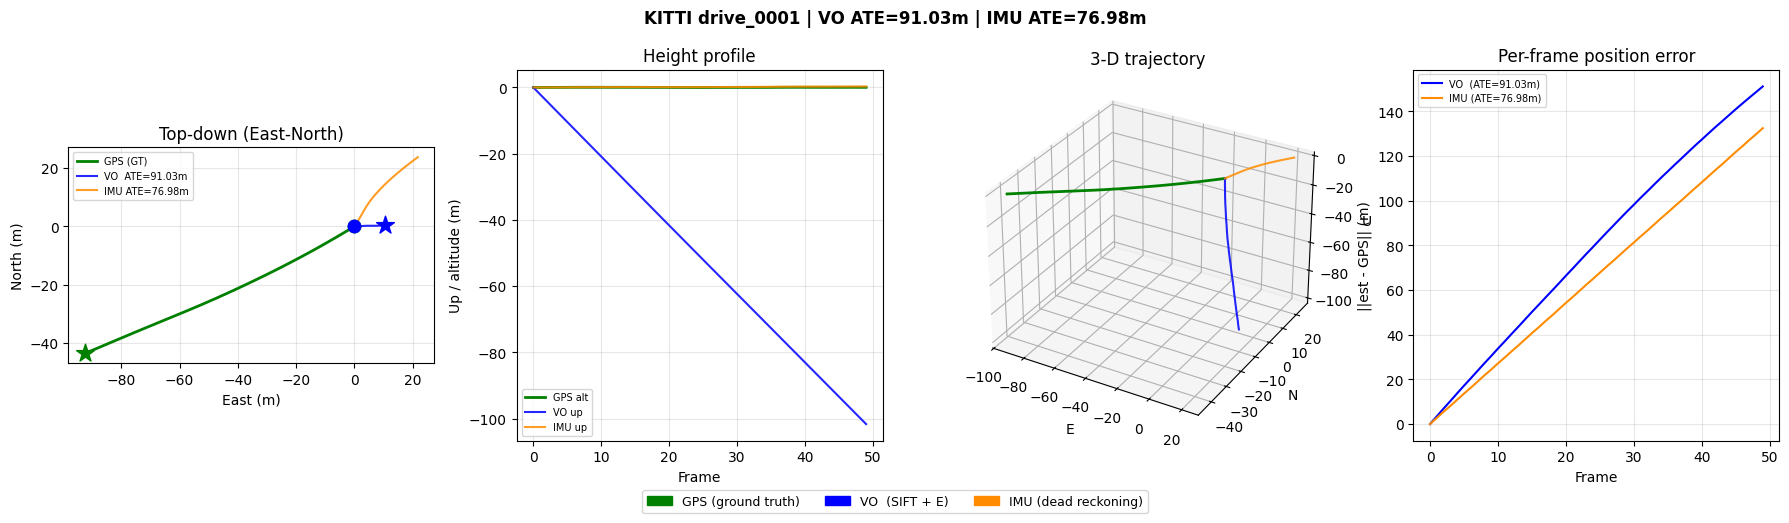

In [10]:
def plot_comparison(vo, imu, gps, ate_vo, ate_imu, stats):
    fig = plt.figure(figsize=(18, 5))

    # Top-down East-North
    ax1 = fig.add_subplot(141)
    ax1.plot(gps[:,0], gps[:,1], 'g-',  lw=2,   label='GPS (GT)')
    ax1.plot(vo[:,0],  vo[:,1],  'b-',  lw=1.5, label=f'VO  ATE={ate_vo:.2f}m', alpha=0.85)
    ax1.plot(imu[:,0], imu[:,1], '-',   lw=1.5, color='darkorange',
             label=f'IMU ATE={ate_imu:.2f}m', alpha=0.85)
    ax1.scatter(*gps[0,:2],  c='green', s=80, zorder=6)
    ax1.scatter(*gps[-1,:2], c='green', marker='*', s=180, zorder=6)
    ax1.scatter(*vo[0,:2],   c='blue',  s=80, zorder=6)
    ax1.scatter(*vo[-1,:2],  c='blue',  marker='*', s=180, zorder=6)
    ax1.set_xlabel('East (m)'); ax1.set_ylabel('North (m)')
    ax1.set_title('Top-down (East-North)')
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3); ax1.set_aspect('equal')

    # Height profile
    ax2 = fig.add_subplot(142)
    x = range(len(gps))
    ax2.plot(x, gps[:,2], 'g-',  lw=2,   label='GPS alt')
    ax2.plot(x, vo[:,2],  'b-',  lw=1.5, label='VO up',  alpha=0.85)
    ax2.plot(x, imu[:,2], '-',   lw=1.5, color='darkorange',
             label='IMU up', alpha=0.85)
    ax2.set_xlabel('Frame'); ax2.set_ylabel('Up / altitude (m)')
    ax2.set_title('Height profile')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    # 3-D
    ax3 = fig.add_subplot(143, projection='3d')
    ax3.plot(gps[:,0], gps[:,1], gps[:,2], 'g-',  lw=2)
    ax3.plot(vo[:,0],  vo[:,1],  vo[:,2],  'b-',  lw=1.5, alpha=0.85)
    ax3.plot(imu[:,0], imu[:,1], imu[:,2], '-',   lw=1.5,
             color='darkorange', alpha=0.85)
    ax3.set_xlabel('E'); ax3.set_ylabel('N'); ax3.set_zlabel('U')
    ax3.set_title('3-D trajectory')

    # Per-frame error
    ax4 = fig.add_subplot(144)
    err_vo  = np.linalg.norm(vo  - gps, axis=1)
    err_imu = np.linalg.norm(imu - gps, axis=1)
    ax4.plot(err_vo,  'b-',  lw=1.5, label=f'VO  (ATE={ate_vo:.2f}m)')
    ax4.plot(err_imu, '-',   lw=1.5, color='darkorange',
             label=f'IMU (ATE={ate_imu:.2f}m)')
    skip_idx = [i for i,s in enumerate(stats) if s['skipped']]
    if skip_idx:
        ax4.scatter(skip_idx, err_vo[skip_idx], c='red', s=40,
                    zorder=5, label='VO skipped')
    ax4.set_xlabel('Frame'); ax4.set_ylabel('||est - GPS|| (m)')
    ax4.set_title('Per-frame position error')
    ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3)

    gp = mpatches.Patch(color='green',     label='GPS (ground truth)')
    bp = mpatches.Patch(color='blue',       label='VO  (SIFT + E)')
    op = mpatches.Patch(color='darkorange', label='IMU (dead reckoning)')
    fig.legend(handles=[gp,bp,op], loc='lower center', ncol=3,
               fontsize=9, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(
        f'KITTI drive_0001 | VO ATE={ate_vo:.2f}m | IMU ATE={ate_imu:.2f}m',
        fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


plot_comparison(vo_s, imu_c, gps_c, ate_vo, ate_imu, stats)


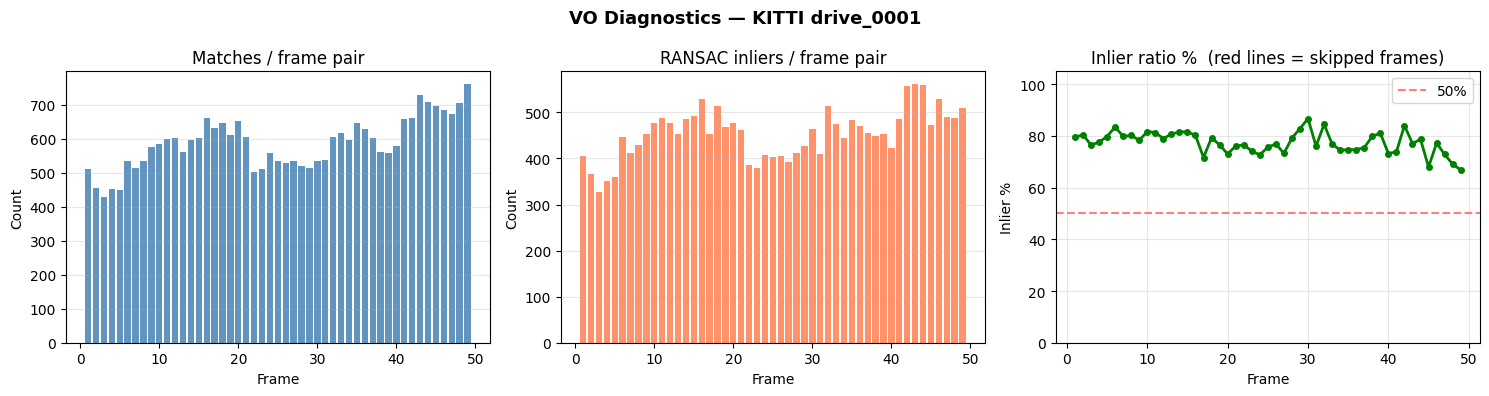

Avg matches  : 587
Avg inliers  : 454
Avg inlier % : 77.4%
Skipped      : 0 / 49


In [11]:
frame_ids  = list(range(1, len(stats)+1))
n_matches  = [s['matches'] for s in stats]
n_inliers  = [s['inliers'] for s in stats]
inlier_pct = [i/m*100 if m>0 else 0 for i,m in zip(n_inliers,n_matches)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(frame_ids, n_matches, color='steelblue', alpha=0.85)
axes[0].set_title('Matches / frame pair')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(frame_ids, n_inliers, color='coral', alpha=0.85)
axes[1].set_title('RANSAC inliers / frame pair')
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Count')
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].plot(frame_ids, inlier_pct, 'g-o', lw=2, markersize=4)
axes[2].axhline(50, color='red', ls='--', alpha=0.5, label='50%')
for sf in [i+1 for i,s in enumerate(stats) if s['skipped']]:
    axes[2].axvline(sf, color='red', alpha=0.3, lw=0.8)
axes[2].set_title('Inlier ratio %  (red lines = skipped frames)')
axes[2].set_xlabel('Frame'); axes[2].set_ylabel('Inlier %')
axes[2].set_ylim(0, 105); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('VO Diagnostics — KITTI drive_0001', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Avg matches  : {np.mean(n_matches):.0f}')
print(f'Avg inliers  : {np.mean(n_inliers):.0f}')
print(f'Avg inlier % : {np.mean(inlier_pct):.1f}%')
print(f'Skipped      : {sum(1 for s in stats if s["skipped"])} / {len(stats)}')


---
## Bonus — Raw IMU Signals

Even small constant bias in ax/ay/az integrates into growing velocity error,
then quadratically growing position error — this is why pure IMU drifts.


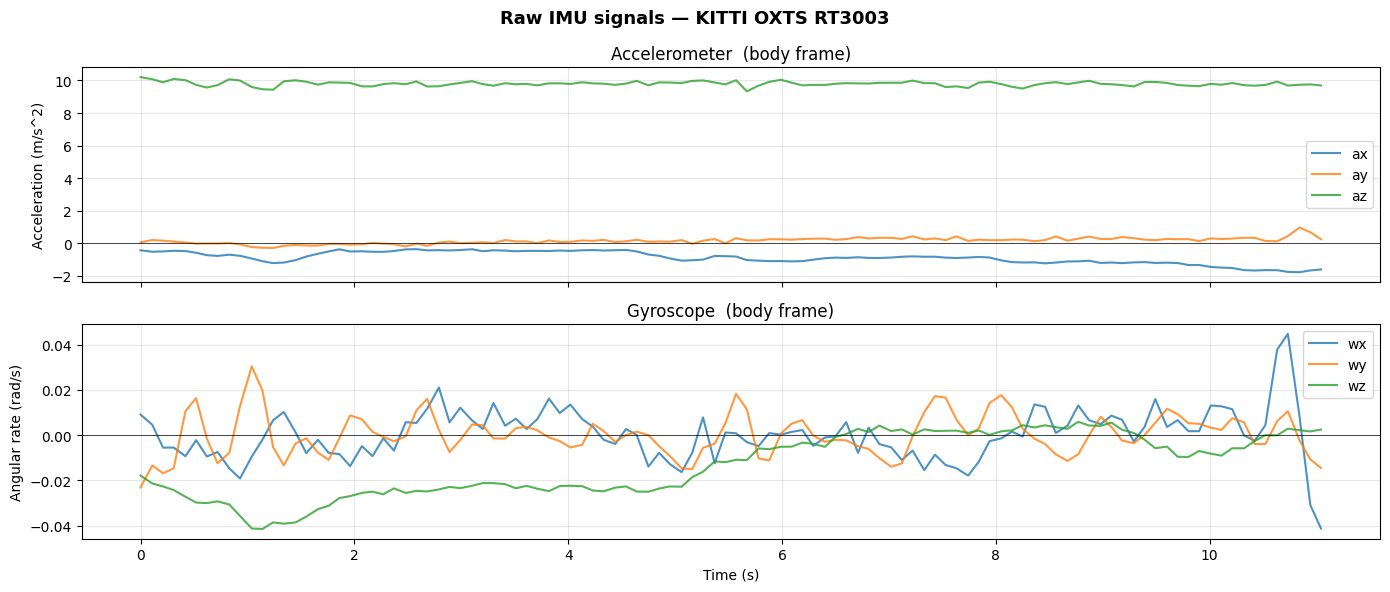

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(oxts_ts, oxts_data[:,11], label='ax', alpha=0.8)
axes[0].plot(oxts_ts, oxts_data[:,12], label='ay', alpha=0.8)
axes[0].plot(oxts_ts, oxts_data[:,13], label='az', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_ylabel('Acceleration (m/s^2)')
axes[0].set_title('Accelerometer  (body frame)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(oxts_ts, oxts_data[:,17], label='wx', alpha=0.8)
axes[1].plot(oxts_ts, oxts_data[:,18], label='wy', alpha=0.8)
axes[1].plot(oxts_ts, oxts_data[:,19], label='wz', alpha=0.8)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angular rate (rad/s)')
axes[1].set_title('Gyroscope  (body frame)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Raw IMU signals — KITTI OXTS RT3003', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Summary

| Method | Strengths | Weaknesses |
|--------|-----------|------------|
| VO (SIFT+E) | No quadratic drift, geometry-consistent | No metric scale, fails on blur |
| IMU only | Metric scale, 100 Hz, handles fast motion | Bias -> t^2 position drift |
| **VIO (fused)** | Metric scale, bounded drift, robust | Needs calibration, complex |

### What real VIO systems add
| Component | Purpose |
|-----------|--------|
| IMU pre-integration (Forster 2015) | Integrate on SO(3) manifold, avoid linearisation |
| EKF / factor graph | Jointly optimise camera + IMU states + biases |
| Online bias estimation | Correct accelerometer and gyro drift in real time |
| Loop closure | Detect revisited places, correct global drift |

**VINS-Mono** and **LIO-SAM** implement all of this and reach
centimetre-level accuracy on sequences like this one.
